In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
                                     GlobalMaxPooling1D, Dense, Dropout,
                                     Concatenate)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('UCI_Credit_Card.csv')


print(f"Γραμμές: {df.shape[0]}, Στήλες: {df.shape[1]}")

print(df.isnull().sum())

print(np.isinf(df.select_dtypes(include=np.number)).sum())

print("\n")
print(df['default.payment.next.month'].value_counts())
print(f"\nΠοσοστό default: {df['default.payment.next.month'].mean()*100:.1f}%")

Γραμμές: 30000, Στήλες: 25
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0


In [3]:
#Αφαιρεση του ID
df = df.drop(columns=['ID'])

#Ορισμος στοχου
y = df['default.payment.next.month'].values

In [4]:
#Ορισμος σταθερων μεταβλητων
static_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']

In [5]:
#Ορισμος μεταβαλομενων μεταβλητων
temporal_cols = [
    'PAY_0',    'PAY_2',    'PAY_3',    'PAY_4',    'PAY_5',    'PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]


In [6]:
X_static = df[static_cols].values
X_temporal = df[temporal_cols].values

In [7]:
X_st_cv, X_st_test, X_te_cv, X_te_test, y_cv, y_test = train_test_split(X_static, X_temporal, y, test_size=0.15, random_state=42, stratify=y)

In [8]:
scaler_s_final = StandardScaler()
scaler_t_final = StandardScaler()

X_st_cv_scaled = scaler_s_final.fit_transform(X_st_cv)
X_te_cv_scaled = scaler_t_final.fit_transform(X_te_cv)
X_te_cv_scaled_3d = X_te_cv_scaled.reshape(-1, 6, 3)

X_st_test = scaler_s_final.transform(X_st_test)
X_te_test = scaler_t_final.transform(X_te_test)
X_te_test = X_te_test.reshape(-1, 6, 3)

In [9]:
print(f"CV data:   Static {X_st_cv.shape} | Temporal {X_te_cv.shape}")
print(f"Test data: Static {X_st_test.shape} | Temporal {X_te_test.shape}")
print(f"\nDefault rate — CV: {y_cv.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")

CV data:   Static (25500, 5) | Temporal (25500, 18)
Test data: Static (4500, 5) | Temporal (4500, 6, 3)

Default rate — CV: 22.1% | Test: 22.1%


In [10]:
X_cv_flat   = np.concatenate([X_st_cv_scaled, X_te_cv_scaled], axis=1)
X_test_flat = np.concatenate([X_st_test, X_te_test.reshape(len(X_te_test), -1)], axis=1)

In [11]:
kf_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs_lr = []

for fold, (train_idx, val_idx) in enumerate(kf_lr.split(X_cv_flat, y_cv)):
    X_tr, X_val = X_cv_flat[train_idx], X_cv_flat[val_idx]
    y_tr, y_val = y_cv[train_idx],      y_cv[val_idx]

    lr_fold = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr_fold.fit(X_tr, y_tr)

    y_prob = lr_fold.predict_proba(X_val)[:, 1]
    auc_f  = roc_auc_score(y_val, y_prob)
    fold_aucs_lr.append(auc_f)
    print(f"Fold {fold+1} AUC: {auc_f:.3f}")

print(f"\nLogistic Regression Mean AUC: {np.mean(fold_aucs_lr):.3f} ± {np.std(fold_aucs_lr):.3f}")

# Τελικό μοντέλο στο πλήρες CV set για προβλέψεις στο test
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_cv_flat, y_cv)
y_prob_lr = lr.predict_proba(X_test_flat)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)
SomerD_lr = 2 * auc_lr - 1
print(f"\nTest AUC: {auc_lr:.3f} | Somer's D: {SomerD_lr:.3f}")

Fold 1 AUC: 0.704
Fold 2 AUC: 0.731
Fold 3 AUC: 0.721
Fold 4 AUC: 0.732
Fold 5 AUC: 0.740

Logistic Regression Mean AUC: 0.726 ± 0.012

Test AUC: 0.709 | Somer's D: 0.419


In [12]:
def build_hybrid_cnn():

    #  Conv1D για Temporal Features
    input_temporal = Input(shape=(6, 3), name='temporal_input')

    x = Conv1D(filters=64, kernel_size=3, activation='relu', name='conv1')(input_temporal)
    x = BatchNormalization(name='bn1')(x)
    x = Conv1D(filters=128, kernel_size=2, activation='relu', name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = GlobalMaxPooling1D(name='pooling')(x)

    #  Dense για Static Features
    input_static = Input(shape=(5,), name='static_input')

    s = Dense(32, activation='relu', name='dense_static')(input_static)
    s = BatchNormalization(name='bn_static')(s)

    #  Συνένωση και Classification Head
    combined = Concatenate(name='concatenate')([x, s])

    z = Dense(64, activation='relu', name='dense_head')(combined)
    z = Dropout(0.3, name='dropout')(z)
    output = Dense(1, activation='sigmoid', name='output')(z)

    #  Δημιουργία Μοντέλου
    model = Model(inputs=[input_temporal, input_static], outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['AUC']
    )

    return model


model = build_hybrid_cnn()

In [13]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_st_cv, y_cv)):
    print(f"\n  FOLD {fold+1}/5  ")

    # Split fold
    X_st_tr = X_st_cv[train_idx]
    X_st_val = X_st_cv[val_idx]
    X_te_tr = X_te_cv[train_idx]
    X_te_val = X_te_cv[val_idx]
    y_tr  = y_cv[train_idx]
    y_val =  y_cv[val_idx]

    # Scaling — fit ΜΟΝΟ στο train του fold
    sc_s = StandardScaler()
    sc_t = StandardScaler()
    X_st_tr  = sc_s.fit_transform(X_st_tr)
    X_st_val = sc_s.transform(X_st_val)
    X_te_tr  = sc_t.fit_transform(X_te_tr)
    X_te_val = sc_t.transform(X_te_val)

    # Reshape
    X_te_tr  = X_te_tr.reshape(-1, 6, 3)
    X_te_val = X_te_val.reshape(-1, 6, 3)

    # Class weights
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict = {0: cw[0], 1: cw[1]}

    # Νέο μοντέλο για κάθε fold
    model = build_hybrid_cnn()

    es = EarlyStopping(monitor='val_loss', patience=10,
                       restore_best_weights=True, verbose=0)

    model.fit(
        x=[X_te_tr, X_st_tr], y=y_tr,
        validation_data=([X_te_val, X_st_val], y_val),
        epochs=100, batch_size=256,
        class_weight=cw_dict,
        callbacks=[es],
        verbose=0
    )

    y_prob_fold = model.predict([X_te_val, X_st_val]).flatten()
    auc_fold    = roc_auc_score(y_val, y_prob_fold)
    fold_aucs.append(auc_fold)
    print(f"Fold {fold+1} AUC: {auc_fold:.3f}")

print(f"\nCNN Mean AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")


  FOLD 1/5  
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 1 AUC: 0.760

  FOLD 2/5  
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 2 AUC: 0.781

  FOLD 3/5  
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 3 AUC: 0.762

  FOLD 4/5  
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 4 AUC: 0.767

  FOLD 5/5  
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 5 AUC: 0.781

CNN Mean AUC: 0.770 ± 0.009


In [14]:
#  5-Fold CV για XGBoost
kf_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs_xgb = []

for fold, (train_idx, val_idx) in enumerate(kf_xgb.split(X_cv_flat, y_cv)):
    X_tr, X_val = X_cv_flat[train_idx], X_cv_flat[val_idx]
    y_tr, y_val = y_cv[train_idx],     y_cv[val_idx]

    neg_f, pos_f = np.bincount(y_tr)
    spw = neg_f / pos_f

    model_xgb = XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=spw,
        objective='binary:logistic', eval_metric='auc',
        random_state=42, n_jobs=-1,
        early_stopping_rounds=20
    )
    model_xgb.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  verbose=False)

    y_prob = model_xgb.predict_proba(X_val)[:, 1]
    auc_f  = roc_auc_score(y_val, y_prob)
    fold_aucs_xgb.append(auc_f)
    print(f"Fold {fold+1} AUC: {auc_f:.3f}")

print(f"\nXGBoost Mean AUC: {np.mean(fold_aucs_xgb):.3f} ± {np.std(fold_aucs_xgb):.3f}")

neg_final, pos_final = np.bincount(y_cv)
spw_final = neg_final / pos_final

X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_cv_flat, y_cv, test_size=0.1, random_state=42, stratify=y_cv)

xgb = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=spw_final,
    objective='binary:logistic', eval_metric='auc',
    random_state=42, n_jobs=-1,
    early_stopping_rounds=20
)

xgb.fit(X_tr_final, y_tr_final,
        eval_set=[(X_val_final, y_val_final)],
        verbose=False)

y_prob_xgb = xgb.predict_proba(X_test_flat)[:, 1]
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)
somers_xgb = 2 * auc_xgb - 1
print(f"\nTest AUC: {auc_xgb:.3f} | Somer's D: {somers_xgb:.3f}")

Fold 1 AUC: 0.773
Fold 2 AUC: 0.795
Fold 3 AUC: 0.773
Fold 4 AUC: 0.773
Fold 5 AUC: 0.799

XGBoost Mean AUC: 0.783 ± 0.012

Test AUC: 0.783 | Somer's D: 0.566


In [15]:
cw = compute_class_weight('balanced', classes=np.unique(y_cv), y=y_cv)

final_model = build_hybrid_cnn()
final_model.fit(
    x=[X_te_cv_scaled_3d, X_st_cv_scaled], y=y_cv,
    epochs=100, batch_size=256,
    class_weight={0: cw[0], 1: cw[1]},
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)],
    verbose=1
)

y_prob_cnn = final_model.predict([X_te_test, X_st_test]).flatten()
auc_cnn    = roc_auc_score(y_test, y_prob_cnn)
somers_cnn = 2 * auc_cnn - 1

print(f"\n{'Μετρική':<15} {'Log. Reg.':>12} {'XGBoost':>10} {'Hybrid CNN':>12}")
print(f"{'AUC':<15} {auc_lr:>12.3f} {auc_xgb:>10.3f} {auc_cnn:>12.3f}")
print(f"{'Somer D':<15} {SomerD_lr:>12.3f} {somers_xgb:>10.3f} {somers_cnn:>12.3f}")

print(f"\nCNN vs Logistic Regression: {(auc_cnn - auc_lr)*100:+.2f}%")
print(f"CNN vs XGBoost:             {(auc_cnn - auc_xgb)*100:+.2f}%")

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - AUC: 0.7177 - loss: 0.6446 - val_AUC: 0.7386 - val_loss: 0.6550
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.7574 - loss: 0.5861 - val_AUC: 0.7604 - val_loss: 0.6074
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.7694 - loss: 0.5729 - val_AUC: 0.7789 - val_loss: 0.5707
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.7742 - loss: 0.5678 - val_AUC: 0.7767 - val_loss: 0.5501
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.7791 - loss: 0.5630 - val_AUC: 0.7834 - val_loss: 0.5154
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - AUC: 0.7832 - loss: 0.5593 - val_AUC: 0.7853 - val_loss: 0.5706
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - AUC: 0.7860 - loss: 0.5567 - val_AUC: 0.7786 - val_loss: 0.5529
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.7895 - loss: 0.5518 - val_AUC: 0.7869 - val_loss: 0.5667
Epoch 9/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.7

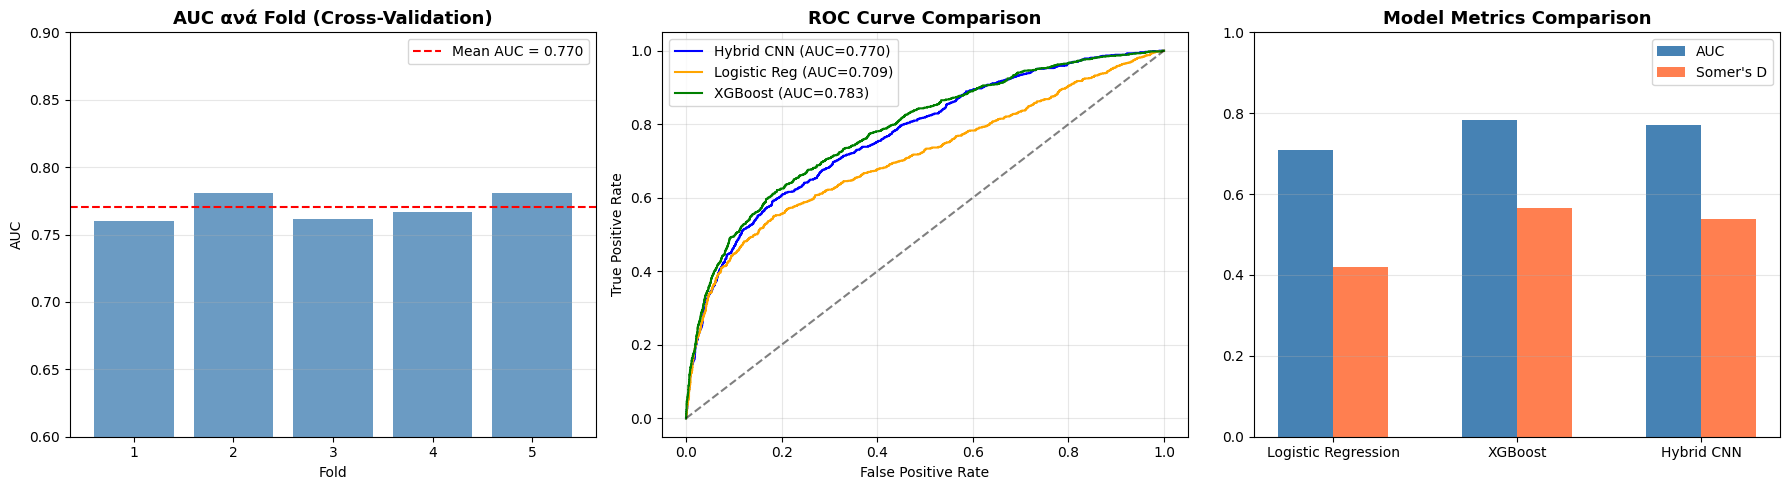

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Graph 1: AUC ανά Fold
axes[0].bar(range(1, 6), fold_aucs, color='steelblue', alpha=0.8)
axes[0].axhline(np.mean(fold_aucs), color='red', linestyle='--', label=f'Mean AUC = {np.mean(fold_aucs):.3f}')
axes[0].set_title('AUC ανά Fold (Cross-Validation)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUC')
axes[0].set_ylim(0.6, 0.9)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

#  Graph 2: ROC Curve
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr_cnn, tpr_cnn, label=f'Hybrid CNN (AUC={auc_cnn:.3f})', color='blue')
axes[1].plot(fpr_lr,  tpr_lr,  label=f'Logistic Reg (AUC={auc_lr:.3f})', color='orange')
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', color='green')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#  Graph 3: Metrics Bar Chart
models = ['Logistic Regression', 'XGBoost', 'Hybrid CNN']
aucs   = [auc_lr,    auc_xgb,    auc_cnn]
somers = [SomerD_lr, somers_xgb, somers_cnn]

x = np.arange(len(models))
w = 0.3
axes[2].bar(x - w/2, aucs,   width=w, label='AUC',       color='steelblue')
axes[2].bar(x + w/2, somers, width=w, label="Somer's D", color='coral')
axes[2].set_title('Model Metrics Comparison', fontsize=13, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

